# Notebook H1 — Hybrid Recommendation System

This notebook combines **Content-Based Filtering** (TF-IDF cosine similarity) and
**Collaborative Filtering** (User-KNN) into a single weighted-hybrid model.

### Pipeline
1. Load data and pre-trained CF models (from notebook 06)
2. Build content-similarity matrix from courses
3. Run a train/test split (same strategy as prior notebooks)
4. Compute hybrid scores with a blending weight **α** (CF) + **(1–α)** (Content)
5. Sweep α from 0 → 1 to find the optimal blend
6. Compare Hybrid vs. standalone CF and Content-Based baselines
7. Save results and models for downstream notebooks (explainability, evaluation, …)

### Metrics
- RMSE, MAE
- HitRate@10, Precision@10, Recall@10, NDCG@10, Coverage

## 0 · Imports & Paths

In [ ]:
from pathlib import Path
import sys
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Paths ──────────────────────────────────────────────────────────────────────
# This notebook lives in  <project_root>/hybrid/
# Everything else (data, models, results) is one level up.
HYBRID_DIR   = Path('.').resolve()           # .../hybrid/
PROJECT_ROOT = HYBRID_DIR.parent             # .../

DATA_RAW       = PROJECT_ROOT / 'data'    / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data'    / 'processed'
FIGURES_DIR    = HYBRID_DIR   / 'figures'
MODELS_DIR     = HYBRID_DIR   / 'models'
RESULTS_DIR    = HYBRID_DIR   / 'results'

# ── Add project root so utils_recommender is importable ───────────────────────
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(HYBRID_DIR))

import utils_hybrid as uh
import utils_recommender as ur   # re-used for evaluate_content_model

uh.ensure_dirs(FIGURES_DIR, MODELS_DIR, RESULTS_DIR)
print('Project root :', PROJECT_ROOT)
print('Hybrid dir   :', HYBRID_DIR)

Project root : C:\Users\habee\Desktop\school\4th_year\term 2\course_recommendation1\XplainaV301
Hybrid dir   : C:\Users\habee\Desktop\school\4th_year\term 2\course_recommendation1\XplainaV301\HybridModel


## 1 · Load Data

In [2]:
ratings_full, courses = uh.load_hybrid_data(DATA_RAW, DATA_PROCESSED)

print(f'ratings_full : {ratings_full.shape}  |  users: {ratings_full["user"].nunique()}  |  items: {ratings_full["item"].nunique()}')
print(f'courses      : {courses.shape}')
ratings_full.head(3)

ratings_full : (233487, 3)  |  users: 34082  |  items: 307
courses      : (307, 17)


,user,item,rating
0,1889878,CC0101EN,3.0
1,1342067,CL0101EN,3.0
2,1990814,ML0120ENv3,3.0


## 2 · Train / Test Split

In [3]:
train_df, test_df = uh.train_test_split_by_user(
    ratings_full, min_user_ratings=5, test_size=0.2, seed=42
)

print(f'Train : {train_df.shape}')
print(f'Test  : {test_df.shape}')

Train : (189876, 3)
Test  : (43611, 3)


## 3 · Content-Based Similarity Matrix

TF-IDF over course title + genre tags.  # we could have loaded it - we need to save it 

In [ ]:
sim_df = ur.create_content_similarity(courses)
tf_idf = sim_df['tfidf_similarity']
print(f'Similarity matrix : {tf_idf.shape}')
sim_df.iloc[:4, :4]


Similarity matrix : (307, 307)


,ML0201EN,ML0122EN,GPXX0ZG0EN,RP0105EN
ML0201EN,1.000000,0.0,0.082906,0.000000
ML0122EN,0.000000,1.0,0.000000,0.000000
GPXX0ZG0EN,0.082906,0.0,1.000000,0.053151
RP0105EN,0.000000,0.0,0.053151,1.000000


## 4 · Collaborative Filtering Predictions

We first try to load the pre-trained User-KNN predictions saved by notebook 06.
If the pickle files are not available, we retrain inline.

In [ ]:
# Try loading pre-trained models from the parent models/ folder
PARENT_MODELS = PROJECT_ROOT / 'models'
pred_user_knn = uh.load_cf_models(PARENT_MODELS)

[utils_hybrid] Loaded CF models from C:\Users\habee\Desktop\school\4th_year\term 2\course_recommendation1\XplainaV301\models
  Users with CF predictions : 34082


## 5 · Hybrid Recommendations (fixed α = 0.5)

A first look at the hybrid model with an equal blend of CF and Content signals.

In [6]:
ALPHA = 0.5   # CF weight;  (1 - ALPHA) → Content weight
TOP_N = 10

hybrid_recs = uh.build_hybrid_predictions(
    train_df=train_df,
    cf_predictions=pred_user_knn,
    sim_df=sim_df,
    alpha=ALPHA,
    top_n=TOP_N,
    normalize=True,
)

print(f'Hybrid recs built for {len(hybrid_recs)} users  |  α={ALPHA}')

Hybrid recs built for 34082 users  |  α=0.5


In [7]:
# ── Sample recommendation for a random user ────────────────────────────────────
sample_user = list(hybrid_recs.keys())[0]
sample_recs = uh.recommend_for_user(sample_user, hybrid_recs, courses, top_n=TOP_N)
print(f'Top-{TOP_N} recommendations for user {sample_user}:')
sample_recs[['COURSE_ID', 'TITLE', 'hybrid_score']]

Top-10 recommendations for user -181:


,COURSE_ID,TITLE,hybrid_score
0,excourse89,javascript jquery and json,0.351850
1,excourse88,javascript basics,0.256074
2,excourse90,programming foundations with javascript html ...,0.162001
3,excourse87,html css and javascript for web developers,0.141115
4,GPXX03HFEN,fundamentals of javascript through rock paper ...,0.136971
5,excourse92,introduction to web development,0.105790
6,OS0101EN,introduction to open source,0.100276
7,GPXX0UMSEN,integrating restful services with a reactive s...,0.087098
8,LB0105ENv1,reactive architecture reactive microservices,0.083528
9,CC0150EN,building cloud native and multicloud applications,0.078667


## 6 · Evaluate Hybrid @ α = 0.5

In [8]:
metrics_hybrid_05 = uh.evaluate_hybrid(
    hybrid_recs=hybrid_recs,
    test_df=test_df,
    train_df=train_df,
    top_n=TOP_N,
    n_users=200,
    seed=42,
)

pd.DataFrame([metrics_hybrid_05], index=[f'Hybrid (α={ALPHA})']).round(4)

,RMSE,MAE,HitRate@10,Precision@10,Recall@10,NDCG@10,Coverage
Hybrid (α=0.5),1.7539,1.3893,0.77,0.108,0.6442,0.4475,0.3876


## 7 · Alpha Sweep — Finding the Best Blend Weight
it is does the same task as the above functions , but what makes it special is that it runs more than one hybrid call with diffrent "a" values

We evaluate the hybrid model across α ∈ {0.0, 0.1, …, 1.0}.
- **α = 0** → pure content-based  
- **α = 1** → pure collaborative filtering

In [ ]:
sweep_df = uh.alpha_sweep(
    train_df=train_df,
    test_df=test_df,
    cf_predictions=pred_user_knn,
    sim_df=sim_df,
    alphas=[round(a * 0.1, 1) for a in range(11)],
    top_n=TOP_N,
    n_users=200,
    seed=42,
)

sweep_df.round(4)

,RMSE,MAE,HitRate@10,Precision@10,Recall@10,NDCG@10,Coverage
alpha,,,,,,,
0.0,1.1052,0.5900,0.385,0.0435,0.2804,0.1733,0.4039
0.1,1.3443,0.8310,0.525,0.0620,0.3953,0.2507,0.4137
0.2,1.4802,0.9912,0.605,0.0745,0.4583,0.3134,0.4202
0.3,1.6142,1.1673,0.670,0.0885,0.5289,0.3801,0.4104
0.4,1.7117,1.3115,0.730,0.1005,0.5996,0.4280,0.3811
0.5,1.7539,1.3893,0.770,0.1080,0.6442,0.4475,0.3876
0.6,1.7143,1.3559,0.770,0.1075,0.6432,0.4472,0.3909
0.7,1.6794,1.3289,0.770,0.1075,0.6432,0.4467,0.3909
0.8,1.6448,1.3020,0.770,0.1075,0.6432,0.4465,0.3909


Saved figure → C:\Users\habee\Desktop\school\4th_year\term 2\course_recommendation1\XplainaV301\HybridModel\figures\hybrid_alpha_sweep.png


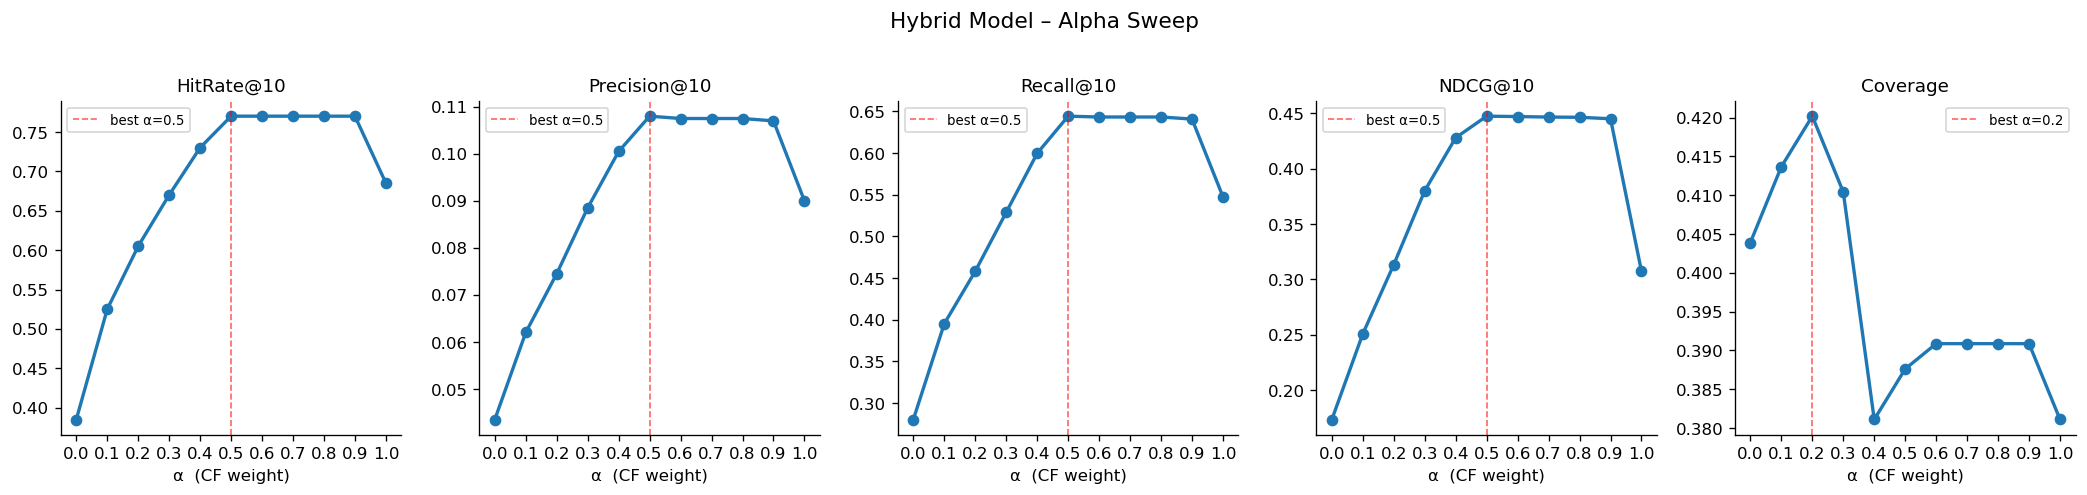

In [10]:
uh.plot_alpha_sweep(sweep_df, figures_dir=FIGURES_DIR)

# "a" with value of 0.5 has been chosen due to its great performance with the evlaution metric NDCG@10 " And also on the other metrics

In [11]:
best_alpha = sweep_df['NDCG@10'].idxmax()
print(f'Best α by NDCG@10 : {best_alpha}')
print(sweep_df.loc[best_alpha].round(4).to_string())

Best α by NDCG@10 : 0.5
RMSE            1.7539
MAE             1.3893
HitRate@10      0.7700
Precision@10    0.1080
Recall@10       0.6442
NDCG@10         0.4475
Coverage        0.3876


## 8 · Final Hybrid Model at Best α

In [12]:
hybrid_recs_best = uh.build_hybrid_predictions(
    train_df=train_df,
    cf_predictions=pred_user_knn,
    sim_df=sim_df,
    alpha=best_alpha,
    top_n=TOP_N,
    normalize=True,
)

metrics_hybrid_best = uh.evaluate_hybrid(
    hybrid_recs=hybrid_recs_best,
    test_df=test_df,
    train_df=train_df,
    top_n=TOP_N,
    n_users=200,
    seed=42,
)

pd.DataFrame([metrics_hybrid_best], index=[f'Hybrid (α={best_alpha})']).round(4)

,RMSE,MAE,HitRate@10,Precision@10,Recall@10,NDCG@10,Coverage
Hybrid (α=0.5),1.7539,1.3893,0.77,0.108,0.6442,0.4475,0.3876


## 9 · Baseline Comparisons

Re-evaluate the standalone CF and Content-Based models using the same
test split and number of sampled users so the numbers are directly comparable.

In [ ]:
# ── Collaborative Filtering baselines ─────────────────────────────────────────
metrics_user_knn = ur.evaluate_cf(
    pred_user_knn, test_df, train_df, top_n=TOP_N, n_users=200, seed=42
)


In [ ]:
# ── Content-Based baselines ────────────────────────────────────────────────────
# Build BoW similarity as well for a second content baseline
sim_df_bow = uh.build_content_similarity(courses, method='bow')

metrics_tfidf = ur.evaluate_content_model(
    sim_df, ratings_full, top_n=TOP_N, n_users=200, seed=42
)


In [ ]:
# ── Compile comparison table ───────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Content-TF-IDF'         : metrics_tfidf,
   
    'CF-User-KNN'            : metrics_user_knn,

    f'Hybrid (α={best_alpha})': metrics_hybrid_best,
}).T.round(4)

comparison

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>RMSE</th>
      <th>MAE</th>
      <th>HitRate@10</th>
      <th>Precision@10</th>
      <th>Recall@10</th>
      <th>NDCG@10</th>
      <th>Coverage</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Content-TF-IDF</th>
      <td>0.0173</td>
      <td>0.0012</td>
      <td>0.4650</td>
      <td>0.0510</td>
      <td>0.2822</td>
      <td>0.1761</td>
      <td>1.0000</td>
    </tr>
    <tr>
      <th>Content-BoW</th>
      <td>0.0173</td>
      <td>0.0012</td>
      <td>0.4600</td>
      <td>0.0515</td>
      <td>0.2764</td>
      <td>0.1713</td>
      <td>1.0000</td>
    </tr>
    <tr>
      <th>CF-User-KNN</th>
      <td>0.0296</td>
      <td>0.0144</td>
      <td>0.7059</td>
      <td>0.0876</td>
      <td>0.5740</td>
      <td>0.3267</td>
      <td>0.3420</td>
    </tr>
    <tr>
      <th>Hybrid (α=0.5)</th>
      <td>1.7539</td>
      <td>1.3893</td>
      <td>0.7700</td>
      <td>0.1080</td>
      <td>0.6442</td>
      <td>0.4475</td>
      <td>0.3876</td>
    </tr>
  </tbody>
</table>
</div>

Saved figure → C:\Users\habee\Desktop\school\4th_year\term 2\course_recommendation1\XplainaV301\HybridModel\figures\hybrid_model_comparison.png


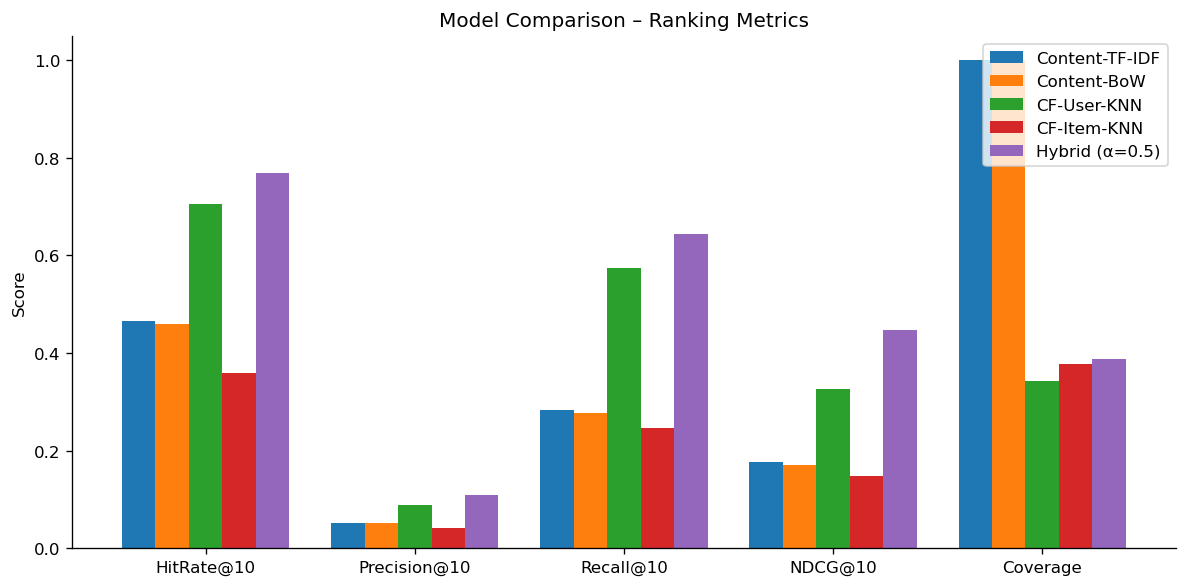

In [16]:
uh.plot_model_comparison(comparison, figures_dir=FIGURES_DIR)

## 10 · Save Results & Artifacts

In [17]:
# ── Results CSV ────────────────────────────────────────────────────────────────
comparison.to_csv(RESULTS_DIR / 'results_hybrid_comparison.csv')
sweep_df.to_csv(RESULTS_DIR / 'results_hybrid_alpha_sweep.csv')
print('Saved results CSV files to', RESULTS_DIR)

# ── Pickle: best hybrid recommendations ───────────────────────────────────────
with open(MODELS_DIR / 'H1_hybrid_recs_best.pkl', 'wb') as f:
    pickle.dump(hybrid_recs_best, f)

# ── Pickle: content similarity matrix (needed for explainability notebook) ────
with open(MODELS_DIR / 'H1_sim_df_tfidf.pkl', 'wb') as f:
    pickle.dump(sim_df, f)

# ── Pickle: metadata for downstream notebooks ──────────────────────────────────
hybrid_meta = {
    'best_alpha'  : best_alpha,
    'top_n'       : TOP_N,
    'cf_model'    : 'User-KNN (k=20)',
    'content_model': 'TF-IDF cosine similarity',
    'train_shape' : train_df.shape,
    'test_shape'  : test_df.shape,
}
with open(MODELS_DIR / 'H1_hybrid_meta.pkl', 'wb') as f:
    pickle.dump(hybrid_meta, f)

print('Saved model artifacts to', MODELS_DIR)
print('\nHybrid meta:', hybrid_meta)

Saved results CSV files to C:\Users\habee\Desktop\school\4th_year\term 2\course_recommendation1\XplainaV301\HybridModel\results
Saved model artifacts to C:\Users\habee\Desktop\school\4th_year\term 2\course_recommendation1\XplainaV301\HybridModel\models

Hybrid meta: {'best_alpha': np.float64(0.5), 'top_n': 10, 'cf_model': 'User-KNN (k=20)', 'content_model': 'TF-IDF cosine similarity', 'train_shape': (189876, 3), 'test_shape': (43611, 3)}


## Summary

| Artifact | Location |
|---|---|
| `results_hybrid_comparison.csv` | `hybrid/results/` |
| `results_hybrid_alpha_sweep.csv` | `hybrid/results/` |
| `H1_hybrid_recs_best.pkl` | `hybrid/models/` |
| `H1_sim_df_tfidf.pkl` | `hybrid/models/` |
| `H1_hybrid_meta.pkl` | `hybrid/models/` |
| `hybrid_alpha_sweep.png` | `hybrid/figures/` |
| `hybrid_model_comparison.png` | `hybrid/figures/` |

The next notebooks in the `hybrid/` folder can load these artifacts directly
without re-training (e.g. `H2_evaluation.ipynb`, `H3_explainability.ipynb`, …).